In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import trange
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.style.use('seaborn-whitegrid')
import numpy as np

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")
print("Device:", device)

Device: cuda:0


### Read Basket Option Data

In [3]:
base_filename = 'basket_option100000x10'

In [4]:
# Basket data stored in 10 files - load and concatenate
basket_data_list = list()
for i in range(0,10):
    new_basket_data = pd.read_csv(base_filename + str(i) + '.csv', index_col=[0])
    basket_data_list.append(new_basket_data) 
    
basket_data = pd.concat(basket_data_list)
basket_data.reset_index(inplace=True)

In [5]:
drop_list = ['index','errorEstimate', 'samples', 'processTime']
basket_dataset = basket_data.drop(drop_list, axis=1)
basket_dataset.head()

,maturity,stockPrice0,vols0,stockPrice1,vols1,stockPrice2,vols2,stockPrice3,vols3,stockPrice4,...,rho_1_3,rho_1_4,rho_1_5,rho_2_3,rho_2_4,rho_2_5,rho_3_4,rho_3_5,rho_4_5,optionValue
0,1754.0,139.974320,0.844889,200.206481,0.207645,123.416367,0.346701,159.791389,0.274293,93.192129,...,0.819724,0.732051,0.902798,0.706413,0.163182,0.482526,0.472884,0.763127,0.849645,3.565121
1,118.0,202.711806,0.996762,139.314227,0.369033,148.596855,0.076906,199.978031,0.070139,176.758286,...,0.767361,0.864755,0.040217,0.928540,0.691265,0.695442,0.802020,0.756128,0.758161,26.976843
2,1152.0,162.726830,0.208185,109.970356,0.535469,128.037467,0.417780,165.198347,0.427270,143.178562,...,0.570650,-0.157536,-0.053319,0.233544,0.783259,0.062310,0.566972,-0.104687,0.211983,0.990318
3,1472.0,269.293618,0.925964,145.242447,0.862780,93.936122,0.220165,186.665573,0.008977,195.630469,...,0.208341,0.325957,0.018602,0.503989,0.131426,-0.311904,0.723854,-0.095374,0.163246,0.593236
4,487.0,196.146214,0.344726,178.081162,0.356272,191.648697,0.950077,106.455096,0.504395,220.452820,...,-0.091080,0.114085,0.017817,0.281075,0.600811,0.422767,0.585918,0.619463,0.746065,6.444476


### Split Data

In [6]:
train_df = basket_dataset[:-40000]
test_df = basket_dataset[-40000:-20000]
validate_df = basket_dataset[-20000:]

In [7]:
def prepareData(df):
    y = pd.DataFrame(df['optionValue'])
    X = df.drop(['optionValue'], axis=1)
    return X, y

In [8]:
X_train, y_train = prepareData(train_df)
X_test, y_test = prepareData(test_df)
X_val, y_val = prepareData(validate_df)

### Standard Scaling

In [9]:
standard_scalar = StandardScaler()
X_train = standard_scalar.fit_transform(X_train)
X_test = standard_scalar.transform(X_test)
X_val = standard_scalar.transform(X_val)

### Build Model

In [10]:
def train_model(model, train_loader, test_loader, loss_fn, optimizer, epochs):
    train_errors, test_errors = [], []
    train_rmse_errors, test_rmse_errors = [], []

    tqdm_epoch = trange(epochs)
    for epoch in tqdm_epoch:
        model.train()
        train_loss, train_sq_sum = 0.0, 0.0

        # Training
        for batch_X, batch_y in train_loader:
            # Forward pass
            outputs = model(batch_X)
            loss = loss_fn(outputs, batch_y)
            train_sq_sum += torch.sum((outputs - batch_y) ** 2).item()
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch_X.size(0)

        train_loss /= len(train_loader.dataset)
        train_rmse = np.sqrt(train_sq_sum / len(train_loader.dataset))
        train_errors.append(train_loss)
        train_rmse_errors.append(train_rmse)
        
        # Evaluation on test set
        model.eval()
        test_loss, test_sq_sum = 0.0, 0.0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X)
                loss = loss_fn(outputs, batch_y)
                test_sq_sum += torch.sum((outputs - batch_y) ** 2).item()
                test_loss += loss.item() * batch_X.size(0)

        test_loss /= len(test_loader.dataset)
        test_rmse = np.sqrt(test_sq_sum / len(test_loader.dataset))
        test_errors.append(test_loss)
        test_rmse_errors.append(test_rmse)

        tqdm_epoch.set_description(f"Epoch {epoch+1}/{epochs} - Train loss: {train_loss:.4f}, \
            Test loss: {test_loss:.4f}, Train RMSE: {train_rmse:.4f}, Test RMSE: {test_rmse:.4f}")

    history = dict()
    history['train_loss'] = train_errors
    history['test_loss'] = test_errors
    history['train_rmse'] = train_rmse_errors
    history['test_rmse'] = test_rmse_errors

    return history

In [14]:
no_epochs = 100
batch_size = 2048

In [15]:
train_x = torch.Tensor(X_train).to(device)
train_y = torch.Tensor(y_train.to_numpy()).to(device)
train_dataset = TensorDataset(train_x, train_y)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=10000, 
                                           shuffle=True, drop_last=True)

val_x = torch.Tensor(X_val).to(device)
val_y = torch.Tensor(y_val.to_numpy()).to(device)
val_dataset = TensorDataset(val_x, val_y)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=1000, 
                                          shuffle=False, drop_last=True)

In [16]:
class FeedForwardNN(nn.Module):
    def __init__(self):
        super(FeedForwardNN, self).__init__()
        self.hidden_layers = nn.ModuleList([nn.Linear(28, 200)] + [nn.Linear(200, 200) for _ in range(4)])
        self.output_layer = nn.Linear(200, 1)

    def forward(self, x):
        for layer in self.hidden_layers:
            x = torch.relu(layer(x))
        x = self.output_layer(x)
        return x

### Basic SGD

In [17]:
sgd_model = FeedForwardNN().to(device)

In [18]:
sgd_loss_fn = nn.MSELoss()
sgd_optimizer = optim.SGD(sgd_model.parameters(), lr=0.001)

In [19]:
sgd_dict = train_model(sgd_model, train_loader, val_loader,
                       sgd_loss_fn, sgd_optimizer, no_epochs)

  0%|          | 0/100 [00:00<?, ?it/s]

### Momentum

In [21]:
mom_model = FeedForwardNN().to(device)
mom_loss_fn = nn.MSELoss()
mom_optimizer = optim.SGD(mom_model.parameters(), lr=0.001, momentum=0.9)

mom_dict = train_model(mom_model, train_loader, val_loader,
                       mom_loss_fn, mom_optimizer, no_epochs)

  0%|          | 0/100 [00:00<?, ?it/s]

### Nesterov

In [23]:
nes_model = FeedForwardNN().to(device)
nes_loss_fn = nn.MSELoss()
nes_optimizer = optim.SGD(nes_model.parameters(), lr=0.001, momentum=0.9, nesterov=True)

nes_dict = train_model(nes_model, train_loader, val_loader,
                             nes_loss_fn, nes_optimizer, no_epochs)

  0%|          | 0/100 [00:00<?, ?it/s]

In [24]:
epochs = range(1, no_epochs + 1)

### Plot Validation Loss

In [25]:
def smooth_curve(points, factor=0.9):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

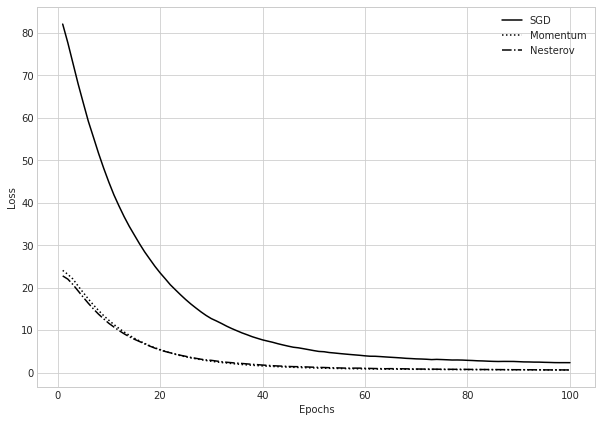

In [32]:
plt.subplots(figsize=(10,7))

loss_values_sgd = smooth_curve(sgd_dict['test_loss'])
loss_values_mom = smooth_curve(mom_dict['test_loss'])
loss_values_nes = smooth_curve(nes_dict['test_loss'])
    
plt.plot(epochs, loss_values_sgd, color='k', linestyle='-', label = 'SGD')
plt.plot(epochs, loss_values_mom, color='k', linestyle=':', label = 'Momentum')
plt.plot(epochs, loss_values_nes, color='k', linestyle='-.', label = 'Nesterov')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('TestBasketMomentumVal.png', dpi=300, bbox_inches='tight')